<a href="https://githubtocolab.com/alsinmr/ConferenceExamples/blob/master/SIMPSON_COLAB.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg"></a>

# SIMPSON Template
Simple template for creating a SIMPSON script, running it, and plotting the results using Jupyter notebooks, including installation and running of SIMPSON in Google Colab.

In [1]:
#Setup for Google Colab
import sys
if 'google.colab' in sys.modules:
    from urllib.request import urlretrieve
    import os
    url="https://inano.au.dk/fileadmin/_migrated/content_uploads/Simpson_Setup_Linux_4.1.1b.tar.bz2"
    filename=os.path.split(url)[1]
    out=urlretrieve(url, filename)
    !tar xf Simpson_Setup_Linux_4.1.1b.tar.bz2
    %cd Simpson\ Setup\ Linux\ 4.1.1
    !./install.sh
    !cd ..
    !simpson

In [2]:
# Imports
from subprocess import Popen, PIPE
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Class to read and run a SIMPSON script
class RunRead():
    def __init__(self):
        self.stdout=None
        self.stderr=None
    def __call__(self,script):
        with open('SIMPSON.tcl','w') as f:f.write(script)
        process = Popen(['simpson', 'SIMPSON.tcl', '-d'], stdout=PIPE, stderr=PIPE)
        self.stdout, self.stderr = [x.decode() for x in process.communicate()]            

        if len(self.stderr):print(self.stderr)
        # Collect the results
        with open('SIMPSON.fid','r') as f:
            while True:
                if 'DATA'==f.readline().strip():break
            S=[]
            while True:
                line=f.readline()
                if 'END'==line.strip():break
                S.append(complex(line.strip().split()[0])+complex(line.strip().split()[1])*1j)
        S=np.array(S)
        return S
run_read=RunRead()

In [17]:
script="""
spinsys {
   channels 13C 1H
   nuclei 13C 1H
   dipole 1 2 -1500 0 0 0
}

par {
   crystal_file     alpha0beta0
   variable rfC     62500
   variable rfH     57500
   variable tsw     5
   variable index   2


   np               512
   proton_frequency 400e6
   start_operator   I2x
   detect_operator  I1x
   method           direct
   gamma_angles     1
   spin_rate        5000
   sw               spin_rate
   variable tsf     200e-6
   verbose          1
}

proc pulseq {} {
   global par
  
   acq_block {
      pulse 200e-6 $par(rfC) x $par(rfH) x
   }
}

proc main {} {
   global par
  
   set f [fsimpson]
   fsave $f $par(name).csdf
}
"""


In [18]:
S=run_read(script)

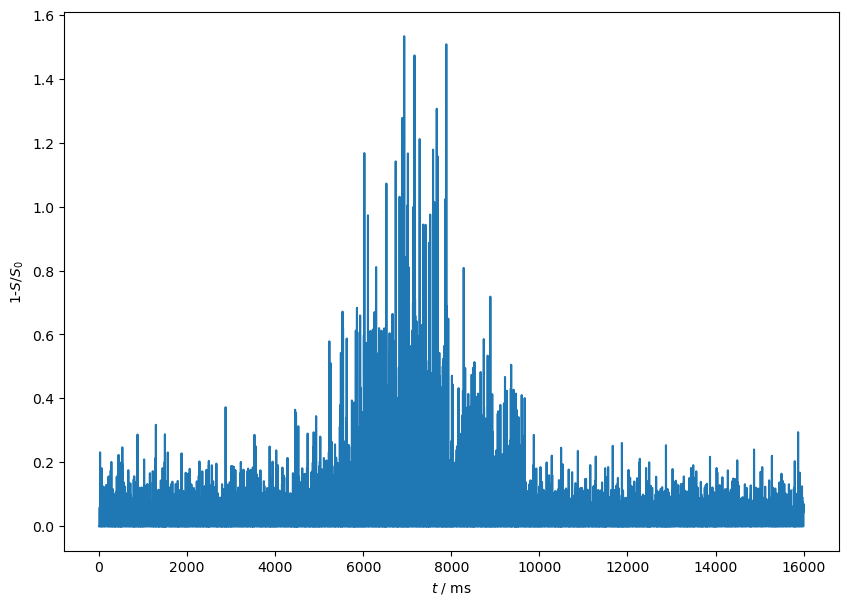

In [19]:
# Plot the results
x=2/10000*1e3*np.arange(len(S))
fig,ax=plt.subplots()
ax.plot(S.real)
ax.set_xlabel(r'$t$ / ms')
ax.set_ylabel(r'1-$S/S_0$')
fig.set_size_inches([10,7])